In [1]:
# Fix stalling - BLAS thread contention.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
# then numpy / sklearn imports

In [2]:
# Import Packages (churn legacy ***clean up***)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import math
from datetime import datetime, timedelta
#from scipy.stats import loguniform, randint, uniform, skew
#import statsmodels.api as sm
#from sklearn.linear_model import LogisticRegression
#from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_s
#from sklearn.model_selection import cross_val_score, StratifiedKFold, Randomize
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier
#from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingCl

# Recomended
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans, AgglomerativeClustering, HDBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats import f_oneway


#import optuna
#import shap

# Set Display Preferences
pd.set_option('display.max_columns', None)
pd.options.display.float_format = "{:.2f}".format

#import gc
np.random.seed(1)

# Load & Transform Data

In [3]:
# Load Instacart data
# Source: https://www.kaggle.com/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/data
aisles = pd.read_csv("data/raw/aisles.csv")
departments = pd.read_csv("data/raw/departments.csv")
order_products__prior = pd.read_csv("data/raw/order_products__prior.csv")
    # contains the products for each past order & then the test & train datasets are for the customers final order
    # len = 32.4M rows (train len only 1.4M & doesnt include eval_set = test)
    # Neither order_products_x contain eval_set = test
    # Does reordered mean that customer has purchased that product in the past. if first purchase, reorder still = 0 instead of null
    # The goal of the original sompetition was to predict which previously purchased products will be in a user’s next order.
order_products__train = pd.read_csv("data/raw/order_products__train.csv")
    # len = 1.38M rows
    # The goal of the original competition was to predict which previously purchased products will be in a user’s next order.
        # so customer i has purchased x different products. objectice is to calc/predict which of those x items shows up in their final order.
        # achieved by calculating a proability (forecast?) for each previous item & if prob > a threshold then predict it will be in final order
            # note: so do we not care about the new items in the final order?????
orders = pd.read_csv("data/raw/orders.csv")
    # contains all orders by all customers in but the prior, train & test sets
    # a customers last order is categorized into train or test
    # a customers first order (order_num=1) has a blank days_since_prior_order which makes sense. sometimes users make multiple orders in 1 day making value of this factor = 0.
        # note: there are a lot of same day orders -> probably dont repeate same products in 1 day
    # max days since reorder is 30 days so 30 actually = 30+
products = pd.read_csv("data/raw/products.csv")


In [4]:
# Join datasets
order_products = pd.concat([order_products__prior, order_products__train], ignore_index=True)
df = orders.merge(order_products, how='inner', on='order_id')
df = df.merge(products, how='left', on='product_id')
df = df.merge(aisles, how='left', on='aisle_id')
df = df.merge(departments, how='left', on='department_id')

## Feature Engineering

In [5]:
### Map pre-assigned department categories to a reduced set of bundled categories for more informative clustering features.
# Department -> product_cat  (beverages intentionally omitted; handled by aisle below)
dept_to_cat = {
    'produce':         'produce',
    'dairy eggs':      'dairy eggs',
    'meat seafood':    'meat seafood', 
    'snacks':          'indulgence',          
    'dry goods pasta': 'staples',
    'canned goods':    'staples',
    'pantry':          'staples',
    'breakfast':       'staples',
    'bulk':            'staples',
    'deli':            'prepared',
    'bakery':          'prepared',
    'frozen':          'prepared',
    'household':       'non_consumables',
    'personal care':   'non_consumables',
    # standalone markers (kept distinct so they can be exluded from CLR block)
    'alcohol':         'alcohol',
    'babies':          'babies',
    'pets':            'pets',
    'international':   'international',
    # drop
    'other':           'other',
    'missing':         'other',}

### Categorise beverages & product category level as beverage signal varies significantly by product type.
# Beverage aisle -> product_cat
bev_to_cat = {
    'water seltzer sparkling water': 'staples',
    'refrigerated':                  'staples',
    'juice nectars':                 'staples',
    'tea':                           'staples',
    'coffee':                        'staples',
    'soft drinks':                   'indulgence',
    'energy sports drinks':          'indulgence',
    'cocoa drink mixes':             'indulgence',}

# Map department (beverages -> NaN here)
df['product_cat'] = df['department'].map(dept_to_cat)
# Map beverages by aisle
bev = df['department'] == 'beverages'
df.loc[bev, 'product_cat'] = df.loc[bev, 'aisle'].map(bev_to_cat)

# Safety check — print unmapped departments/ailes (check for NaN)
print(df['product_cat'].value_counts(dropna=False))

product_cat
produce            9888378
staples            7051743
dairy eggs         5631067
prepared           4657579
indulgence         3510861
non_consumables    1243345
meat seafood        739238
babies              438743
international       281155
alcohol             159294
other               115482
pets                102221
Name: count, dtype: int64


In [6]:
# %%%%% Open question: why do we distinguish between marker vs clr categories
core_cats   = ['produce', 'dairy eggs', 'meat seafood','indulgence', 'staples', 'prepared', 'non_consumables']
marker_cats = ['alcohol', 'babies', 'pets', 'international']

# Transpose item counts by category to a new df
cat_counts = (df[df['product_cat'] != 'other']
              .groupby(['user_id', 'product_cat']).size()
              .unstack(fill_value=0))
# ensure all columns exist
for c in core_cats + marker_cats:                                   
    if c not in cat_counts.columns:
        cat_counts[c] = 0

# CLR block — core categories only
    # Re-expresses each category as its log-representation relative to the customer's own mean basket.
    # Map the composition into unconstrained Euclidean space where distances behave and the values stay interpretable.
    # Note: positive = that customer over-indexes on this category relative to their own mix)
    # Note: fixes sum-to-1 constraint that created spurious dependence + values now live in a flat Euclidean space rahter than a constrained simplex
alpha = 0.5                                                         # additive smoothing -> no zeros
core_smoothed = cat_counts[core_cats].astype(float) + alpha
core_comp = core_smoothed.div(core_smoothed.sum(axis=1), axis=0)    # divide by row total to get smoothed category percentages
log_comp = np.log(core_comp)                                        # take log

clr = log_comp.sub(log_comp.mean(axis=1), axis=0)                   # subtract mean of row from each value in that row
clr.columns = [f'clr_{c}' for c in core_cats]                       # asign column names

# Each category as its log-representation relative to the customer's own mean basket. %%%%% clarify understanding
clr

,clr_produce,clr_dairy eggs,clr_meat seafood,clr_indulgence,clr_staples,clr_prepared,clr_non_consumables
user_id,,,,,,,
1,0.30,1.46,-2.10,2.30,0.30,-2.10,-0.15
2,0.89,1.02,-2.48,0.98,0.43,1.12,-1.97
3,1.76,1.17,-2.59,0.36,0.55,0.25,-1.49
4,0.25,-1.35,-1.35,0.25,0.59,1.35,0.25
5,1.95,1.04,-1.91,-0.81,0.49,0.04,-0.81
...,...,...,...,...,...,...,...
206205,1.53,1.88,-0.73,-1.83,-0.22,1.21,-1.83
206206,0.18,0.32,-2.44,0.56,0.56,1.07,-0.25
206207,1.10,1.14,-0.95,0.33,1.24,0.66,-3.52


In [7]:
# EDA on pct of customers that reorder by category. 
product_cat = df.groupby(['product_cat'], as_index=True).agg(
                                            customers_purchased=('user_id', 'nunique'),
                                            customers_reordered = ('user_id', lambda x: x[df.loc[x.index, 'reordered'] > 0].nunique()))

product_cat['customers_purchased_pct'] = round(product_cat['customers_purchased'] / df['user_id'].nunique() * 100, 2)
product_cat['customers_reordered_pct'] = round(product_cat['customers_reordered'] / df['user_id'].nunique() * 100, 2)
product_cat


,customers_purchased,customers_reordered,customers_purchased_pct,customers_reordered_pct
product_cat,,,,
alcohol,16104,9007,7.81,4.37
babies,34782,19358,16.87,9.39
dairy eggs,191861,165703,93.04,80.36
indulgence,183036,136180,88.76,66.04
international,79357,29510,38.48,14.31
meat seafood,116851,70181,56.67,34.03
non_consumables,140269,67532,68.02,32.75
other,44512,15069,21.59,7.31
pets,15484,8057,7.51,3.91


In [8]:
# Define a new column for organic items based on 'organic' appearing in product_name
df['organic'] = df['product_name'].str.contains('organic', case=False, na=False).astype(int)

In [9]:
# Delete large objects to reduce RAM ussage
del orders, order_products , order_products__prior, order_products__train, bev
del cat_counts, core_comp, core_smoothed, log_comp
#gc.collect() # garbage collection process to reclaim unused memory by finding and destroying unreachable objects

In [10]:
# Calc avg basket size & std dev of avg basket size
basket_sizes = df.groupby(['user_id', 'order_number'], as_index=False).agg(
                                            basket_size=('product_id', 'nunique'),
                                            aisles_breadth=('aisle_id', 'nunique'),
                                            department_breadth=('department_id', 'nunique'))
#basket_sizes = df.groupby(['user_id', 'order_number']).size().reset_index(name='basket_size')

basket_comp = basket_sizes.groupby('user_id').agg(
                                            avg_basket_size=('basket_size', 'mean'),                # Avg basket size of customer_i (small basket vs. large basket shopper)
                                            std_basket_size=('basket_size', 'std'),                 # Variation in basket size of customer_i (routinely basket vs. big swings in behaviour)
                                            avg_aisles_breadth=('aisles_breadth', 'mean'),
                                            std_aisles_breadth=('aisles_breadth', 'std'),           # Redundant - used to calc Relative Standard Deviation
                                            avg_department_breadth=('department_breadth', 'mean'),
                                            std_department_breadth=('department_breadth', 'std')    # Redundant - used to calc Relative Standard Deviation
                                            )

# Scale standard dev to be independent of cx avg volume (Relative Standard Deviation)
basket_comp['rsd_basket_size'] = basket_comp['std_basket_size'] / basket_comp['avg_basket_size']      
basket_comp['rsd_aisles_breadth'] = basket_comp['std_aisles_breadth'] / basket_comp['avg_aisles_breadth']
basket_comp['rsd_department_breadth'] = basket_comp['std_department_breadth'] / basket_comp['avg_department_breadth']

basket_comp

,avg_basket_size,std_basket_size,avg_aisles_breadth,std_aisles_breadth,avg_department_breadth,std_department_breadth,rsd_basket_size,rsd_aisles_breadth,rsd_department_breadth
user_id,,,,,,,,,
1,6.36,2.11,5.55,1.81,3.82,0.60,0.33,0.33,0.16
2,15.07,7.06,8.47,2.47,5.73,1.16,0.47,0.29,0.20
3,7.33,2.10,5.75,1.66,4.08,1.00,0.29,0.29,0.24
4,3.60,2.07,3.00,1.41,3.00,1.41,0.58,0.47,0.47
5,9.20,2.68,7.20,2.59,4.20,1.30,0.29,0.36,0.31
...,...,...,...,...,...,...,...,...,...
206205,12.75,6.13,9.25,2.06,5.00,1.41,0.48,0.22,0.28
206206,4.25,3.23,3.57,1.73,2.81,1.13,0.76,0.49,0.40
206207,13.94,6.04,11.00,5.03,6.31,2.70,0.43,0.46,0.43


In [11]:
# Create binary flags that will be used to calculate clustering factors when aggregating to customer level. 
# Note: Time periods determined by examing purchase density accross day.
df['is_weekend']   = df['order_dow'].le(1)
df['is_morning']   = df['order_hour_of_day'].between(5, 11)
df['is_afternoon'] = df['order_hour_of_day'].between(12, 19)
df['is_night']     = ~df['order_hour_of_day'].between(5, 19)
# Note: These categories are low variance / zero-heavy -> kept as standalone markers distinct from CLR block
df['alcohol_reord']         = (df['product_cat'] == 'alcohol') & (df['reordered'] > 0)
df['babies_reord']          = (df['product_cat'] == 'babies') & (df['reordered'] > 0)
df['pets_reord']            = (df['product_cat'] == 'pets') & (df['reordered'] > 0)
df['international_reord']    = (df['product_cat'] == 'international') & (df['reordered'] > 0)

# Group by user_id & create aggregated customer level measures
df_user_id = df.groupby('user_id').agg(
    T_orders_count          = ('order_number', 'nunique'),      # Target var - Number of orders customer_i made
    T_lt_items_count        = ('product_id', 'count'),          # Target var - Lifetime total items purchased (lifetime purchase volume)
    T_unique_products       = ('product_id',    'nunique'),     # Target var - Count of lifetime distinct products customer_i purchased
    T_unique_aisles         = ('aisle_id',      'nunique'),     # Target var - Count of lifetime distinct aisles customer_i purchased from
    T_unique_departments    = ('department_id', 'nunique'),     # Target var - Count of lifetime distinct departments customer_i purchased from
    unique_days             = ('order_dow', 'nunique'),         # Number of distinct days customer_i made an order (habitual weekend repurchaser or more sporadic)
    weekend_orders_pct      = ('is_weekend',   'mean'),         # Pct of orders placed on the weekend 
    morning_orders_pct      = ('is_morning',   'mean'),         # Pct of orders placed in the morning (5:00am - 11:59am)
    afternoon_orders_pct    = ('is_afternoon', 'mean'),         # Pct of orders placed in the afternoon (12:00pm - 7:59pm)
    night_orders_pct        = ('is_night',     'mean'),         # Pct of orders placed at night (8:00pm - 4:59am) ~ Note: sum-to-1 redundancy
    organic_pct             = ('organic',       'mean'),        # Pct of items customer_i purchased that were organic
    # Marker flags for low variation / zero-heavy categories 
    alcohol_flag            = ('alcohol_reord', 'max'),         # Dummy for customers that have ever reordered an 'alcohol' product
    babies_flag             = ('babies_reord', 'max'),          # Dummy for customers that have ever reordered a 'babies' product
    pets_flag               = ('pets_reord', 'max'),            # Dummy for customers that have ever reordered a 'pets' product
    international_flag      = ('international_reord', 'max'),   # Dummy for customers that have ever reordered an 'international' product
)

# Post group by processing:
df_user_id['T_hundred_orders'] = df_user_id['T_orders_count'].ge(100).astype(int)     # Measure of highest volumn cx with >= 100 purchases (dataset limit of 100 purchases per cx)
df_user_id['alcohol_flag'] = df_user_id['alcohol_flag'].astype(int)             # Convert from boolean to binary for clustering algos
df_user_id['babies_flag'] = df_user_id['babies_flag'].astype(int) 
df_user_id['pets_flag'] = df_user_id['pets_flag'].astype(int)
df_user_id['international_flag'] = df_user_id['international_flag'].astype(int)

In [12]:
### Feature engineering of variables that should exlude first order where reorder unilaterally = 0
# Drop first order (order_number == 1) 
df_less1st = df[df['order_number']!=1].copy()

# Discovery = propensity to add new items at the beggining of their order vs starting with reordering familiar items
df_less1st['discover_n5'] = -1 * (df_less1st['reordered'].where(df_less1st['add_to_cart_order'].le(5))-1)   # value (0 or 1) where cart<=5, else NaN 
df_less1st['discover_n3'] = -1 * (df_less1st['reordered'].where(df_less1st['add_to_cart_order'].le(3))-1)

# Group by User ID
df_user_id_less1st = df_less1st.groupby('user_id').agg(
    reorder_pct         = ('reordered',     'mean'),            # Pct of items purchased that are reorders
    discovery_pct_n5    = ('discover_n5',   'mean'),            # Proxy measure of if purchase intention - Is order discovery based or routine items?
    discovery_pct_n3    = ('discover_n3',   'mean'),            # Note: mean skips NaN --> calcing mean among add_to_cart_order column where val <= 3
    )


# Order level: (one row per order)
order_level = df_less1st.drop_duplicates('order_id')[['user_id', 'order_id', 'days_since_prior_order']].copy()                   # NaN on first order -> auto-excluded
order_level['is_sameday'] = order_level['days_since_prior_order'].eq(0)
order_level['is_under7']  = order_level['days_since_prior_order'].between(1,7)
order_level['is_cap30']   = order_level['days_since_prior_order'].ge(30)
order_level['is_under30'] = order_level['days_since_prior_order'].lt(30)

# Group order level by user id to get purchase recency flags
order_frequency = order_level.groupby('user_id').agg(
    T_avg_days_since_prior      = ('days_since_prior_order', 'mean'),   # Measure: speed of order frequency
    std_days_since_prior        = ('days_since_prior_order', 'std'),    # Redundant - used to calc Relative Standard Deviation
    same_day_repurchase_pct     = ('is_sameday', 'mean'),
    same_week_repurchase_pct    = ('is_under7',   'mean'),
    days_since_over30_pct       = ('is_cap30',   'mean'),
    days_since_under30_pct      = ('is_under30', 'mean')                # sum-to-1 redundancy
)

# Scale standard dev to be independent of cx avg cadence (Relative Standard Deviation)
order_frequency['rsd_days_since_prior'] = order_frequency['std_days_since_prior'] / order_frequency['T_avg_days_since_prior']  

# join reorder rate & discover propensity with order frequency 
df_user_id_less1st = df_user_id_less1st.merge(order_frequency, how='inner', on='user_id')
df_user_id_less1st

,reorder_pct,discovery_pct_n5,discovery_pct_n3,T_avg_days_since_prior,std_days_since_prior,same_day_repurchase_pct,same_week_repurchase_pct,days_since_over30_pct,days_since_under30_pct,rsd_days_since_prior
user_id,,,,,,,,,,
1,0.78,0.16,0.07,19.00,9.03,0.10,0.00,0.10,0.90,0.48
2,0.49,0.33,0.31,16.29,10.27,0.00,0.14,0.21,0.79,0.63
3,0.71,0.22,0.12,12.09,5.38,0.00,0.36,0.00,1.00,0.44
4,0.07,1.00,1.00,13.75,9.50,0.25,0.00,0.00,1.00,0.69
5,0.51,0.50,0.42,11.50,5.45,0.00,0.25,0.00,1.00,0.47
...,...,...,...,...,...,...,...,...,...,...
206205,0.41,0.33,0.22,16.67,11.55,0.00,0.00,0.33,0.67,0.69
206206,0.48,0.46,0.38,3.77,3.29,0.06,0.83,0.00,1.00,0.87
206207,0.66,0.20,0.24,14.33,11.54,0.00,0.40,0.27,0.73,0.80


In [13]:
# Combine data on user_id & start clustering ()
# with K-means, hierarchical, and HDBSCAN compared explicitly; silhouette and stability for evaluation; PCA kept as a diagnostic, not the input, to preserve interpretability.

# merge & organize (dont think I need a train/test split but need to organize by training factors vs target explanitory vs secondary explanitory)
df_joined = df_user_id.merge(df_user_id_less1st, how='inner', on='user_id')
df_joined = df_joined.merge(basket_comp, how='inner', on='user_id')
df_joined = df_joined.merge(clr, how='inner', on='user_id')
df_joined

#del df

,T_orders_count,T_lt_items_count,T_unique_products,T_unique_aisles,T_unique_departments,unique_days,weekend_orders_pct,morning_orders_pct,afternoon_orders_pct,night_orders_pct,organic_pct,alcohol_flag,babies_flag,pets_flag,international_flag,T_hundred_orders,reorder_pct,discovery_pct_n5,discovery_pct_n3,T_avg_days_since_prior,std_days_since_prior,same_day_repurchase_pct,same_week_repurchase_pct,days_since_over30_pct,days_since_under30_pct,rsd_days_since_prior,avg_basket_size,std_basket_size,avg_aisles_breadth,std_aisles_breadth,avg_department_breadth,std_department_breadth,rsd_basket_size,rsd_aisles_breadth,rsd_department_breadth,clr_produce,clr_dairy eggs,clr_meat seafood,clr_indulgence,clr_staples,clr_prepared,clr_non_consumables
user_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,11,70,19,13,7,4,0.24,0.64,0.36,0.00,0.26,0,0,0,0,0,0.78,0.16,0.07,19.00,9.03,0.10,0.00,0.10,0.90,0.48,6.36,2.11,5.55,1.81,3.82,0.60,0.33,0.33,0.16,0.30,1.46,-2.10,2.30,0.30,-2.10,-0.15
2,15,226,121,37,13,5,0.42,0.87,0.13,0.00,0.25,0,0,0,1,0,0.49,0.33,0.31,16.29,10.27,0.00,0.14,0.21,0.79,0.63,15.07,7.06,8.47,2.47,5.73,1.16,0.47,0.29,0.20,0.89,1.02,-2.48,0.98,0.43,1.12,-1.97
3,12,88,33,16,9,4,0.70,0.00,1.00,0.00,0.34,0,0,0,0,0,0.71,0.22,0.12,12.09,5.38,0.00,0.36,0.00,1.00,0.44,7.33,2.10,5.75,1.66,4.08,1.00,0.29,0.29,0.24,1.76,1.17,-2.59,0.36,0.55,0.25,-1.49
4,5,18,17,14,9,3,0.00,0.33,0.67,0.00,0.11,0,0,0,0,0,0.07,1.00,1.00,13.75,9.50,0.25,0.00,0.00,1.00,0.69,3.60,2.07,3.00,1.41,3.00,1.41,0.58,0.47,0.47,0.25,-1.35,-1.35,0.25,0.59,1.35,0.25
5,5,46,28,17,10,3,0.65,0.20,0.80,0.00,0.50,0,0,0,1,0,0.51,0.50,0.42,11.50,5.45,0.00,0.25,0.00,1.00,0.47,9.20,2.68,7.20,2.59,4.20,1.30,0.29,0.36,0.31,1.95,1.04,-1.91,-0.81,0.49,0.04,-0.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206205,4,51,37,20,11,4,0.37,0.00,1.00,0.00,0.41,0,0,0,0,0,0.41,0.33,0.22,16.67,11.55,0.00,0.00,0.33,0.67,0.69,12.75,6.13,9.25,2.06,5.00,1.41,0.48,0.22,0.28,1.53,1.88,-0.73,-1.83,-0.22,1.21,-1.83
206206,67,285,150,50,16,7,0.43,0.01,0.93,0.06,0.31,0,0,0,1,0,0.48,0.46,0.38,3.77,3.29,0.06,0.83,0.00,1.00,0.87,4.25,3.23,3.57,1.73,2.81,1.13,0.76,0.49,0.40,0.18,0.32,-2.44,0.56,0.56,1.07,-0.25
206207,16,223,92,46,14,7,0.32,0.35,0.48,0.17,0.53,0,0,0,0,0,0.66,0.20,0.24,14.33,11.54,0.00,0.40,0.27,0.73,0.80,13.94,6.04,11.00,5.03,6.31,2.70,0.43,0.46,0.43,1.10,1.14,-0.95,0.33,1.24,0.66,-3.52


In [14]:
# Note: Discovery of 14 customers that made all their purchases in a single day - resulting in an undefined rsd_days_since_prior
# Solution: Drop these entries as single day order history breaks core assumption multiple features are built on.
    # Key persona comparison feature, 'purchase cadence' - is meaningless when all purchases are same day.
df_joined = df_joined[~df_joined['rsd_days_since_prior'].isna()]

In [15]:
# Seperate columns by features that will be used to cluster on vs KPIs that will be used to evaluate the business utility of these categories.
clustering_factors = ['reorder_pct', 'organic_pct',
                      'discovery_pct_n5',   # 'discovery_pct_n3' (exluded - high correlation)
                      'avg_basket_size', # 'avg_department_breadth', 'avg_aisle_breadth' (exluded - high correlation)
                      'rsd_basket_size',    # 'rsd_aisles_breadth', 'rsd_department_breadth' (exluded - high correlation)
                      'rsd_days_since_prior',
                      'weekend_orders_pct', 
                      'morning_orders_pct', 'afternoon_orders_pct',   # 'night_orders_pct', (exluded - collinearity)
                      'days_since_over30_pct',
                      'same_day_repurchase_pct', 'same_week_repurchase_pct', 
                      'clr_produce', 'clr_dairy eggs', 'clr_meat seafood', 'clr_indulgence', 'clr_staples', 'clr_prepared', 'clr_non_consumables'
                      ]


#   TARGETS  = volume/exposure/cadence-level outcomes the segments should separate
#   MARKERS  = sparse lifestyle flags used to describe segments (profilers)
holdout_factors = ['T_avg_days_since_prior', # Cadence measure
                   'T_orders_count', 'T_lt_items_count',  # Volume measures
                   'T_unique_products', 'T_unique_aisles', 'T_unique_departments', # Exposure measure
                   # Secondary marker measures
                   'T_hundred_orders',
                   'alcohol_flag', 
                   'babies_flag', 
                   'pets_flag', 
                   'international_flag'
                   ]
# Target cols answers "does this segment retain/engage differently", while marker cols answer "does this segment have more babies/pets than avg."

In [16]:
# INPUTS: cluster on composition, style, and timing features that are roughly invariant to how much someone uses the service.

# OUTPUTS: variabls used as a downstream outcomes that are excluded from the clustering model inputs; 
    # lifetime value (total number of items/purchases), purchase frequency, service integration (cross category purchasing)

# Note: related-but-distinct variables may remain but are expected to show partial mechanical correlation.

## K-means Assumptions (for effective performance)
1. Clusters are roughly spherical / convex:
    - Clusters are represented by their centriod & the obeservations close to that centriod (should look roughly round/spherical rather than elongated or concavely curved).
2. Similar variance across clusters:
    - K-means will only identify best identify clusters that have similar within-cluster spread (cluster with huge variance shouldn't coexist with a very tight cluster).
3. Features are on comparable scales:
    - A variable on a much larger numerical scale would dominate clustering.
4. Euclidean distance between two observations should meaningfully represent how different they are:
    - Broken if variables are categorical, ordinal, heavily skewed, etc.
5. Variables are reasonably independent:
    - Including x & log(x) woudld effectively be double weighted.
6. Data should include few extreme outliers:
    - K-means is very sensitive to outliers because it uses squared distances.
7. The number of clusters (K) is appropriate & meaninful

# EDA

## Correlation Prune

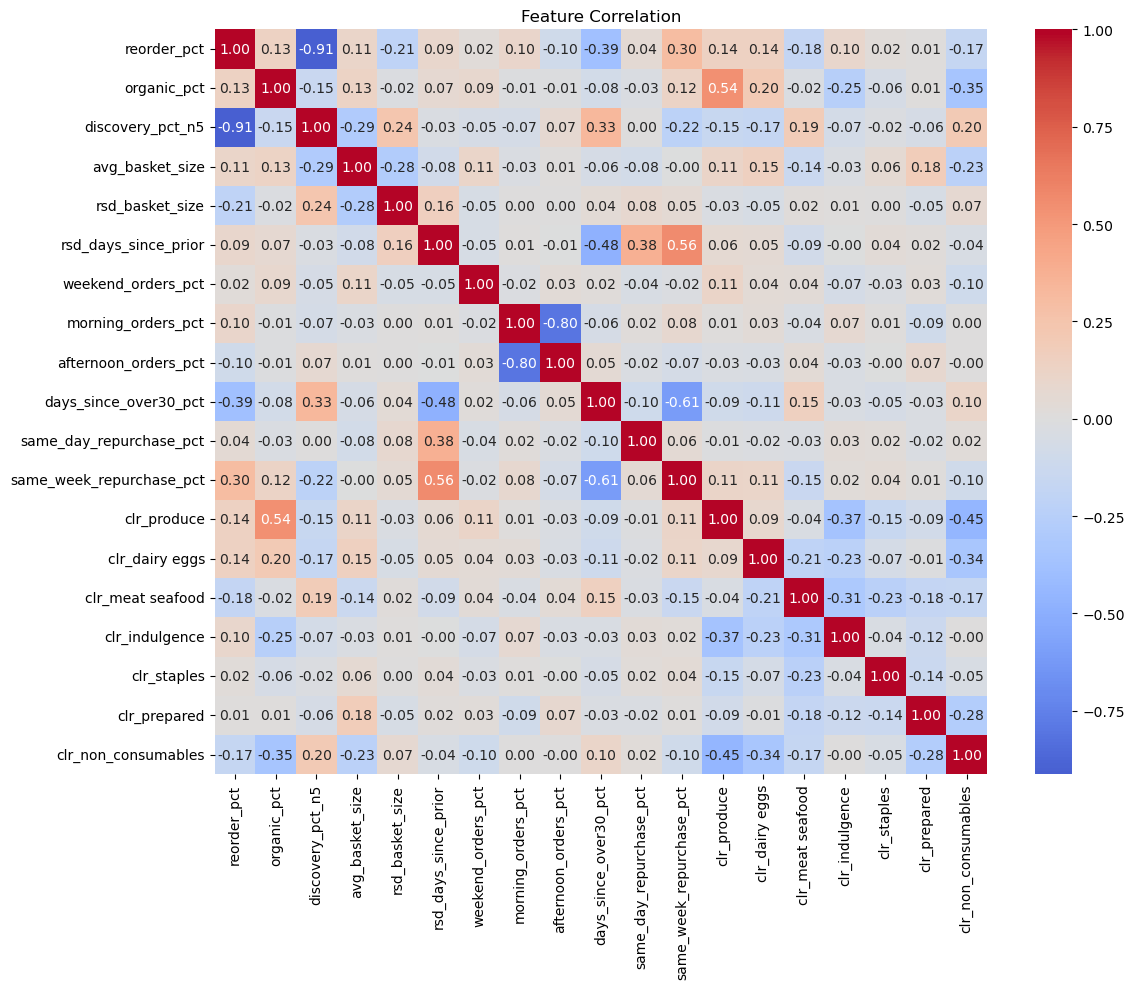

In [17]:
# Prune highly correlated features (correlated inputs effectively act as double-weights and warp Euclidean distance).
# This is the single highest-leverage cleanup. Watch two blocks in particular:
#   (a) the four cadence-derived features (rsd_days_since_prior, days_since_over30_pct,
#       same_day_repurchase_pct, same_week_repurchase_pct) — all slices of one
#       interval distribution; expect some to collapse together.


# For any pair > |0.8| - drop one feature
corr = df_joined[clustering_factors].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, 
            annot=True, fmt=".2f")
plt.title("Feature Correlation")
plt.tight_layout(); plt.show()

In [18]:
# Drop one feature from pairs where corr > |0.8|
clustering_factors.remove('discovery_pct_n5')
clustering_factors.remove('afternoon_orders_pct')

## Visualizing Distributions

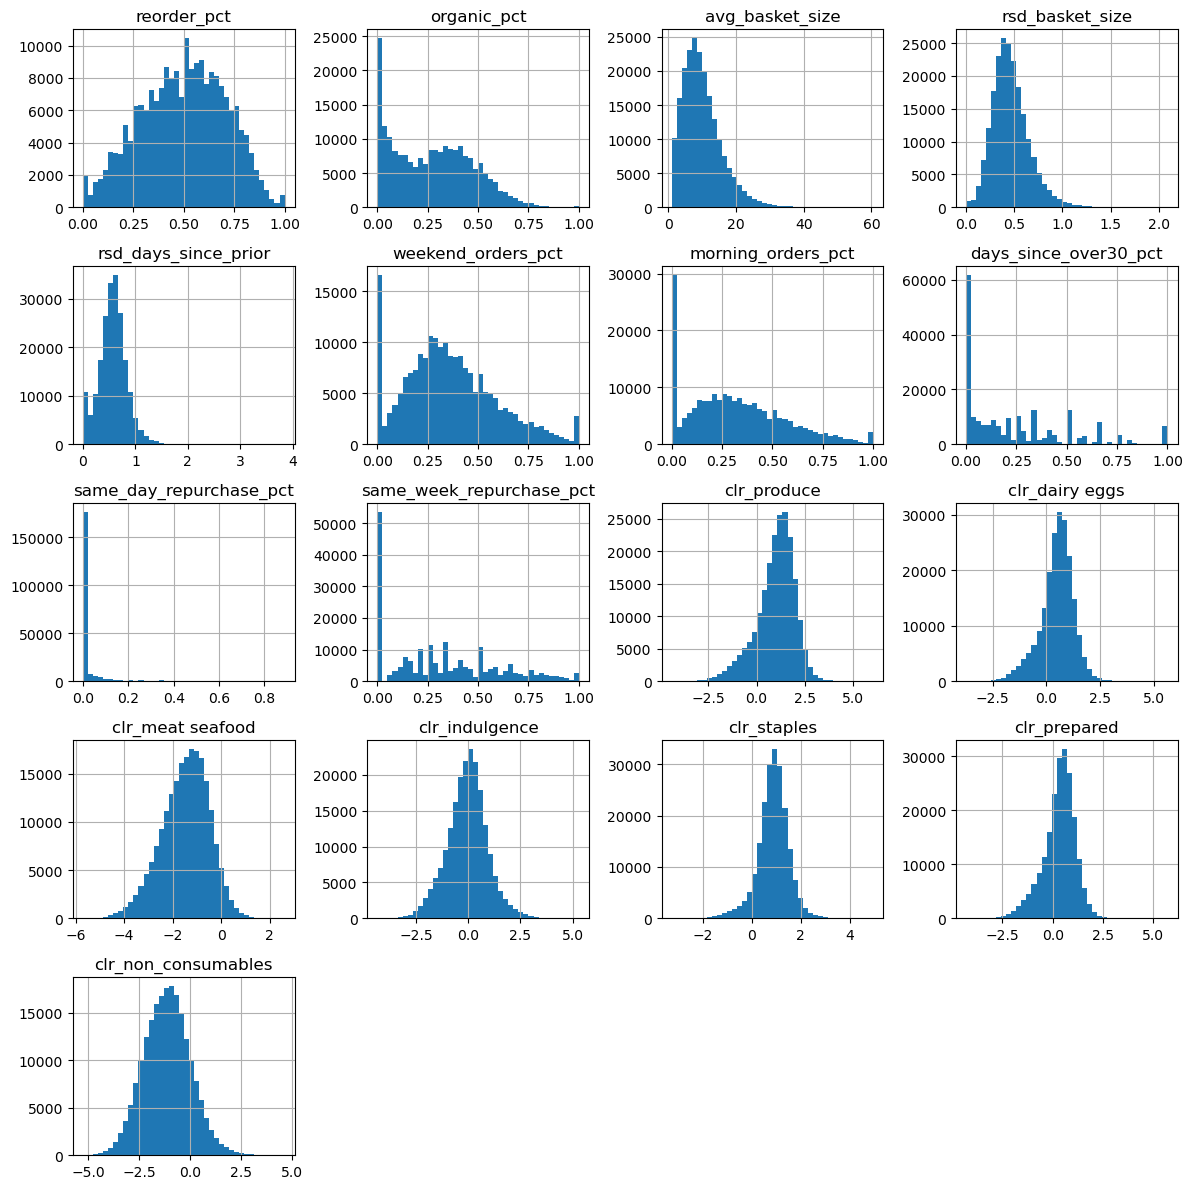

In [19]:
### Distribition / skewness check
# K-means uses squared distance, so a long tails (outliers) pull on centroids 
# Logging can compresses the tail & makes equal ratios ~ equal distances (2->4 items ~ 40->80).
# Note: Do not log bounded ratios (percentage features)
df_joined[clustering_factors].hist(figsize=(12, 12), bins=40)   # reminder: bins = histogram buckets or interval count
plt.tight_layout()
plt.show()

Implication of spikes at zero - not necissarily problematic for K-means. However:
- K-means minimizes squared distance to a mean, and a large point mass at one value plus a spread-out tail is a non-Gaussian, non-spherical shape. 
- The mean sits in the sparse gap between the spike and the tail — a value almost no customer actually has — so the feature pulls clusters around in ways that don't correspond to real groupings.

same_day_repurchase_pct vs. morning_orders_pct etc.
- same_day_repurchase_pct: problematic, but for imbalance, not for zeros. ~174K of 206K customers sit at 0. This isn't a zero-heavy continuous feature but a near-constant one (~90% identical value). A near-constant feature is bad for clustering because after standardizing, the 10% who do place same-day orders become extreme outliers. (K-means, being outlier-sensitive, can waste an entire cluster isolating that tiny tail)
- morning_orders_pct: Despite a zero spike it has real mass spread across the whole range, so it's a proper continuous feature with significant variance.

Conclusion: drop same_day_repurchase_pct & keep the other features dispite value spikes at 0 - then test clustering on them & remove if features have low importance or are not interpretable.

In [20]:
# Drop features with non-gaussian, non-spherical shape 
clustering_factors.remove('same_day_repurchase_pct')

In [21]:
# Logging before clustering to stop a long right tail from letting a handful of extreme customers dominate Euclidean distance and drag centroid
    # Logging compresses the tail equating ratios to distances (2->4 ~ 40->80).
    # Features contributes proportionally rather than dominated by extremes.
    # Log space makes equal ratios equal distances, which matches how basket size scale appropriately (2->4 ≠ 102->104)

skew_cols = ['avg_basket_size', 'rsd_basket_size', 'rsd_days_since_prior']


# General rule: after standardizing, look at skewness, or check how far the max sits in sigma units. 
    # Rough heuristic is skewness above ~1 (or a standardized max beyond ~5-6 sigma) signals a tail worth logging. 
    # below that, leave it (although only harm is just making feature less directly interpretable).
from scipy.stats import skew
for c in skew_cols:                                                 # # np.log1p(x) = ln(𝟏+𝒙)
    print(f"{c}: raw skew {skew(df_joined[c]):.2f} | log1p skew {skew(np.log1p(df_joined[c])):.2f}")    



avg_basket_size: raw skew 1.22 | log1p skew -0.33
rsd_basket_size: raw skew 0.91 | log1p skew 0.38
rsd_days_since_prior: raw skew 0.23 | log1p skew -0.44


- |skew| < 0.5 --> Fairly semetric
- |skew| > 0.5 --> Borderline (check max sigma if factir interpretability is important)
- |skew| > 1 --> Strong skew (log transform)


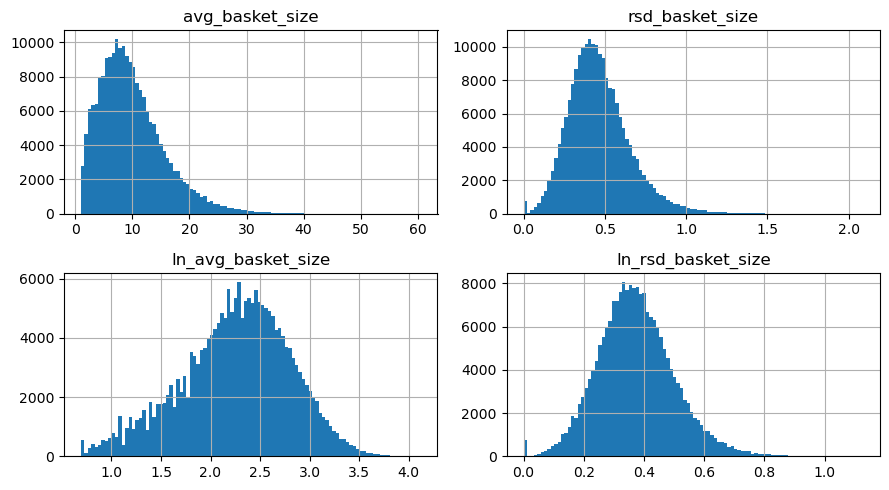

In [22]:
# Remove non-skewed vars from from transforamtion list
skew_cols.remove('rsd_days_since_prior')

# Update skewed columns with its natural log in df_joined & clustering_factors
ln_skew_cols = []
for c in skew_cols:
    ln_c = f'ln_{c}'                                             # log col_name dynamically
    df_joined[ln_c] = np.log1p(df_joined[c])                 
    clustering_factors[clustering_factors.index(c)] = ln_c
    ln_skew_cols.append(ln_c)

# Dispaly distributions before & after log transformation
df_joined[skew_cols + ln_skew_cols].hist(figsize=(9, 5), layout=(2,len(ln_skew_cols)), bins=100)
plt.tight_layout()
plt.show()

In [23]:
# Standardize the input matrix - distance-based methodologies (k-means) get dominated by large-range features.
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_joined[clustering_factors]), index=df_joined[clustering_factors].index, columns=df_joined[clustering_factors].columns)
df_scaled.describe().round(2)

,reorder_pct,organic_pct,ln_avg_basket_size,ln_rsd_basket_size,rsd_days_since_prior,weekend_orders_pct,morning_orders_pct,days_since_over30_pct,same_week_repurchase_pct,clr_produce,clr_dairy eggs,clr_meat seafood,clr_indulgence,clr_staples,clr_prepared,clr_non_consumables
count,206195.00,206195.00,206195.00,206195.00,206195.00,206195.00,206195.00,206195.00,206195.00,206195.00,206195.00,206195.00,206195.00,206195.00,206195.00,206195.00
mean,-0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.37,-1.38,-2.85,-2.95,-2.17,-1.59,-1.33,-0.91,-1.15,-5.34,-5.44,-4.29,-4.44,-6.51,-5.78,-3.61
25%,-0.73,-0.93,-0.62,-0.66,-0.59,-0.70,-0.78,-0.91,-1.15,-0.52,-0.51,-0.65,-0.61,-0.51,-0.52,-0.69
50%,0.03,-0.02,0.09,-0.06,0.02,-0.12,-0.12,-0.31,-0.15,0.15,0.10,0.08,0.04,0.06,0.12,-0.01
75%,0.77,0.75,0.70,0.60,0.59,0.62,0.64,0.54,0.68,0.67,0.63,0.71,0.61,0.59,0.65,0.65
max,2.40,3.67,3.40,5.96,12.50,2.82,2.85,2.94,2.50,5.02,6.63,4.16,5.50,6.41,6.75,5.03


# Fitting K-Means

## Selecting K


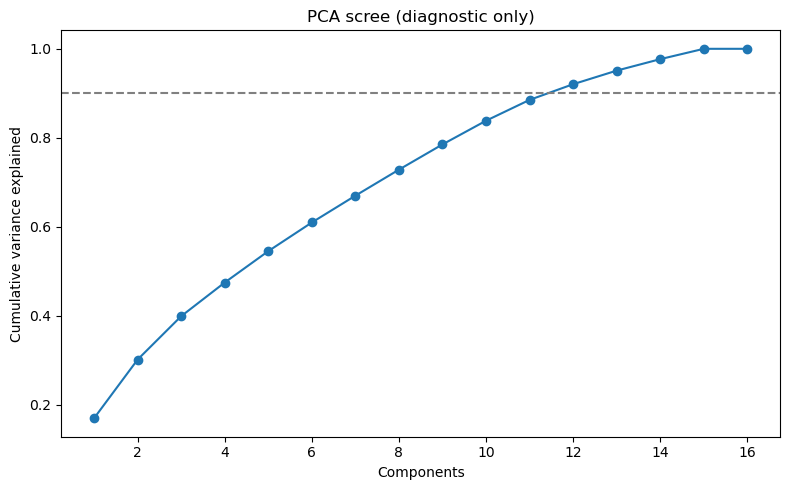

In [24]:
# Structural check of input factos - how many real dimensions of variation exist.
# Note: cluster on the original standardized features, not PCA components. Figure exists only a diagnostic.
pca = PCA().fit(df_scaled)
csum = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(csum) + 1), csum, marker="o")
plt.axhline(0.9, ls="--", c="grey")
plt.xlabel("Components")
plt.ylabel("Cumulative variance explained")
plt.title("PCA scree (diagnostic only)")
plt.tight_layout()
plt.show()

PCA Scree Plot does not have a sharp elbow - variance accumulates gradually with no single dominant component (PC1 is only ~17% and takes 11 components to account for the 90% variance).

Features are largely non-redundant - if inputs were still heavily correlated first few components would have swallowed most of the variance (curve would shoot up then flatten early).

Note: implication for clustering - high intrinsic dimensionality is slightly harder for K-means (distances get less contrasted as dimensions grow).

General approach to PCA scree plot analysis
- The elbow — where the curve bends from steep to flat. That kink marks the number of components capturing the "real" structure before you hit diminishing returns (mostly noise after). A sharp, obvious elbow at component k says "there are k meaningful dimensions here." 
- How fast you reach a variance threshold (ex. 90%): 
    - Few components to threshold = redundant, compressible features. 
    - Many = independent, information-rich features. 

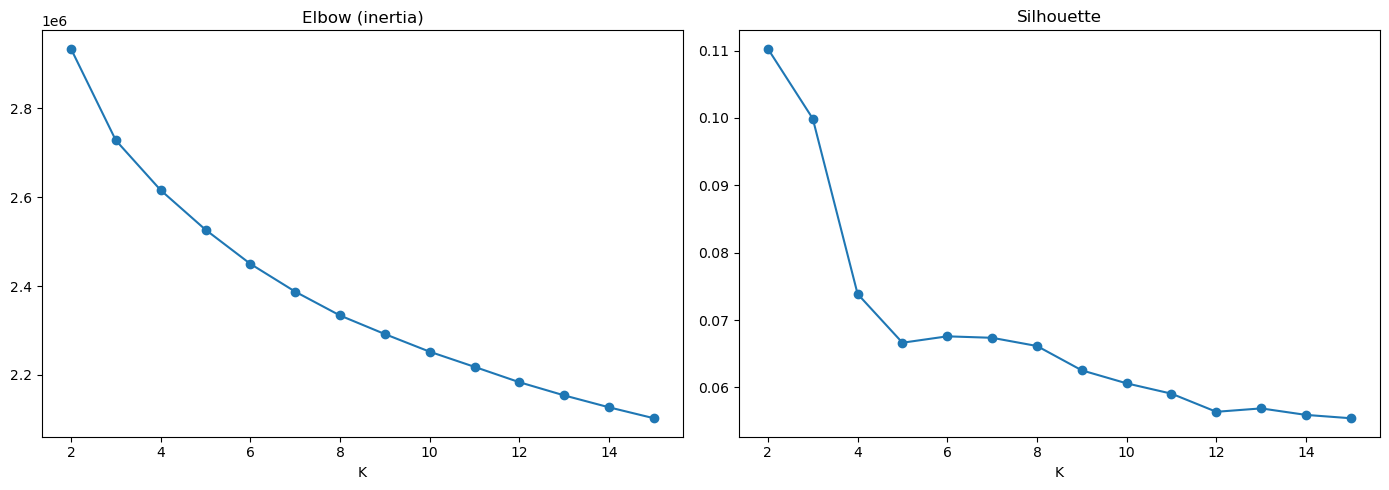

In [25]:
# Silhouette computed on a sample for speed on ~20k rows.
    # Note: silhouette compares each point to all others, so a full silhouette on len(measures) x 206k observation would be an exceedingly expensive calculation
samp_idx = df_scaled.sample(min(20000, len(df_scaled)), random_state=1).index

# Select K using intertia (elbow) & silhouette graphs:
    # inertia (elbow) shows diminishing returns 
    # silhouette scores separation
# Pick a K where silhouette peaks + inertia elbow bends & that yields practical numeber of personas (~4-6)
Ks = range(2, len(clustering_factors))
inertias, sils = [], []

for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=1).fit(df_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(df_scaled.loc[samp_idx], km.predict(df_scaled.loc[samp_idx])))
 
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(list(Ks), inertias, marker="o"); ax[0].set_title("Elbow (inertia)"); ax[0].set_xlabel("K")
ax[1].plot(list(Ks), sils, marker="o");     ax[1].set_title("Silhouette");      ax[1].set_xlabel("K")
plt.tight_layout()
plt.show()

Inertia-Silhouette results: The strongest, cleanest separation in the data is a coarse 2–3 group split. Past 3 groups, subdividing results in clusers sitting closer together (hence the low, flat scores).

Reason for low scores:
1. Behavioural data tents to form soft gradients, not islands — customers shade continuously from one shopping style to the next, so there are no wide empty gaps between clusters and silhouette is structurally low.
2. Model's high dimensionality (scree plot needed ~11 components to account for 90% of variance) which dilutes contrast. In many dimensions, the distance from one cluster to the next becomes more similar (pushing silhouette toward zero). 

- - - - - - - - - - - - - - - - - - - - -
Note: Inertia & Silhouette both score clustering - silhouette measures tightness and separation together, while inertia measures tightness only.
- Inertia: how tight clusters are. 
    - For every observation, take the distance to it's own cluster's center, square it, and sum the squared distance. 
    - Low inertia = customers sit close to their centroids = tight clusters.
        - Inertia limitation: only rewards tightness which always improves with more clusters (more centroids means each point is closer to one, so inertia falls monotonically as K rises)

- Silhouette: how well-separated clusters are (not just how tight). Compares two distances for each observation: 
    - a = average distance to others in their own cluster (cohesion — how well they fit where they are), and 
    - b = average distance to the members of the nearest other cluster (separation — how far the next-best option is). 
    - Score is (b − a) / max(a, b) --> lands between −1 and +1
        - near +1 --> much closer to their own cluster than to any other (confidently well-placed)
        - near 0 --> sitting on the boundary between two clusters
        - negative --> closer to a neighbouring cluster than their own (probably misassigned)

Note: Silhouette score interpreation:
 - 0.7–1.0 = Strong, clean separation (Toy/synthetic data, well-separated blobs, iris)
 - 0.5–0.7 = Reasonable structure (Low-dim data with real groups; image color quantization)
 - 0.25–0.5 = Weak but present structure (Many real business datasets; tabular data with some signal)
 - 0.1–0.25 = Very soft / overlapping (Behavioural & customer data typically lands here)
 - < 0.1 = Little to no cluster structure (High-dim behavioural data, or wrong feature set)
 - < 0 = Misassignment / no structure (Clustering forced onto data with no groups)

Always pair separation metric with 1-stability & 2-whether the segments predict something you didn't cluster on.

### Feature Importance for cluster seperation

In [26]:
# 2 clusters is not a very useful project deliverable. Set test K at ~ideal level for additional testing
TEST_K = 5          # hold K fixed when comparing component range

### Test if reduced dimensionality improves clusters (1-PCA feature set & 2-Reduced feature set)

Note: clusters fit on Principal Components lose interpretability. Objective is to identify benchmark of maximum seperation/silhouette score if clustered on lower dimensional feature set.

In [27]:
# PCA feature set
# Scree plot shows ~11 components acount for 90% variance (variance spread across many weakly-informative dimensions).
# In high dimensions, distances between points converge, mechanically driving silhouette down.
# PCA trade-off: components are linear blends of all features, so a centroids of PCs are not interpretable. 

# Fit PCA and select how many components to keep 
pca_full = PCA(random_state=1).fit(df_scaled)               # Fit PCA on the standardized feature matrix (using all components/input components)
    # Note: Fitting PCA computes the direction along which observatations vary most -> (PC1) 
        # then the direction of next-most variance that's perpendicular to PC1 -> (PC2)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
    # Note: pca_full.explained_variance_ratio_ produces an array with one value per component, 
        # each being the fraction of total variance that component captures


# Two defensible rules for choosing n_components
    # Note: they often disagree — report which you used and why, rather than picking whichever flatters the result.
n_80  = int(np.argmax(cumsum >= 0.80) + 1)                   # option 1 - variance-threshold rule (# of components needed to retain x% of the variance)
        # ^^return the first position where the condition is true
n_kaiser = int((pca_full.explained_variance_ > 1).sum())     # option 2 - Kaiser: keep components explaining more than one standardized feature's worth
        # Note: explained_variance_ returns the variance along each component in absolute units (the eigenvalues), not fractions.
        # Threshold = 1 because inputs were standardized before running PCA to variance = 1.
        # Each original feature contributes 1 unit of variance, so a component with explained_variance_ > 1 is capturing more variance than an original feature
        # Therefore it's summarizing a real, shared pattern across multiple features rather than just re-expressing one feature's worth of scatter. 
        # (so by this logic, a component < 1 is carrying less signal than an individual feature and probably isn't worth keeping)
print(f"components for 80% variance: {n_80} | Kaiser criterion: {n_kaiser}")


components for 80% variance: 10 | Kaiser criterion: 6


In [28]:
### Fit PCA at a test value for K that maximizes silhouette
scores = []
for n in range(2, len(df_scaled.columns) + 1):                          # try every component count
    Xn = PCA(n_components=n, random_state=1).fit_transform(df_scaled)   # Fit PCA components. Then transform & project data onto the new compressed dataset
    Xn = pd.DataFrame(Xn, index=df_scaled.index)                        # Convert numyp array to pandas dataframe
    clust = KMeans(TEST_K, n_init=10, random_state=1).fit(Xn)           # Define kmeans model parameters then fit the compressed data to each cluster
    clust_sub = pd.Series(clust.labels_, index=Xn.index).loc[samp_idx]  # Slice cluster labels for sub-sample (subset used to reduce computational expenditure)
    scores.append({
        "n_components": n,
        "silhouette": silhouette_score(Xn.loc[samp_idx], clust_sub),                    # Calc silhouette score (higher better)
        "min_cluster_pct": pd.Series(clust.labels_).value_counts(normalize=True).min()  # min_cluster_pct = cluster balance metric
                                                                                            # Measures pct of data in the smallest cluster
    })

print(pd.DataFrame(scores).round(3))

    n_components  silhouette  min_cluster_pct
0              2        0.32             0.13
1              3        0.23             0.15
2              4        0.19             0.14
3              5        0.15             0.14
4              6        0.13             0.15
5              7        0.12             0.14
6              8        0.10             0.14
7              9        0.10             0.12
8             10        0.09             0.12
9             11        0.09             0.12
10            12        0.08             0.12
11            13        0.08             0.12
12            14        0.08             0.12
13            15        0.07             0.16
14            16        0.07             0.16


Hypothosis: Exsessive noise dimensions are suppressing discernible structure. 

Test: Identify what number of principal components maximizes for peak silhouette score

Result: Silhouette score decreases monotonically as the number of principal components increases. This demonstrates that low seperation isn't a product of feature count/composition that can be re-engineered away but rather the actual shape of the data. Customer behaviour forms a continuous cloud rather then constrentrate in discrete groups.\ 

Conclusion: Reduction of factors inflates the silhouette score without improving actual cluster structure. Therefore, use all best judgment for 

In [30]:
### Feature importance (which features drove the clustering?)

# K-means (assumes roughly spherical, similar-size, convex clusters; forces every pointinto one)
# Note: centroids read directly as customer personas
kmeans = KMeans(n_clusters=TEST_K, n_init=25, random_state=1)
df_joined['cluster_kmeans'] = kmeans.fit_predict(df_scaled)

# Classifier feature importance in seperating clusters — train simple supervised model to predict the cluster label from the features (prediction score=importances)
    # (catches nonlinear & interaction effects)
labels = df_joined['cluster_kmeans']
rf = RandomForestClassifier(n_estimators=200, random_state=1, n_jobs=1)
rf.fit(df_scaled, labels)
importance = pd.Series(rf.feature_importances_, index=df_scaled.columns).sort_values(ascending=False).round(3)

print("Feature importance (drivers of cluster assignment for TEST_K):")
print(importance.round(3))


# Note: This informs what features should be removed for a reduced clustering set while trying to keep at least one measure per conceptual axis 
    # conceptual axis examples: basket size vs compisition vs frequency vs habitual propensity

Feature importance (drivers of cluster assignment for TEST_K):
clr_meat seafood           0.13
same_week_repurchase_pct   0.12
days_since_over30_pct      0.11
clr_produce                0.10
organic_pct                0.08
ln_avg_basket_size         0.08
clr_non_consumables        0.06
rsd_days_since_prior       0.06
clr_indulgence             0.05
ln_rsd_basket_size         0.05
reorder_pct                0.05
clr_dairy eggs             0.03
clr_prepared               0.03
weekend_orders_pct         0.02
clr_staples                0.02
morning_orders_pct         0.02
dtype: float64


### Clustering on reduced feature set

In [31]:
clustering_factors_reduced = clustering_factors.copy()
clustering_factors_reduced.remove('morning_orders_pct')     # -> low value
clustering_factors_reduced.remove('weekend_orders_pct')     # -> low value
clustering_factors_reduced.remove('days_since_over30_pct')  # infrequent shopper propensity -> corr with rsd_basket_size

clustering_factors_reduced

['reorder_pct',
 'organic_pct',
 'ln_avg_basket_size',
 'ln_rsd_basket_size',
 'rsd_days_since_prior',
 'same_week_repurchase_pct',
 'clr_produce',
 'clr_dairy eggs',
 'clr_meat seafood',
 'clr_indulgence',
 'clr_staples',
 'clr_prepared',
 'clr_non_consumables']

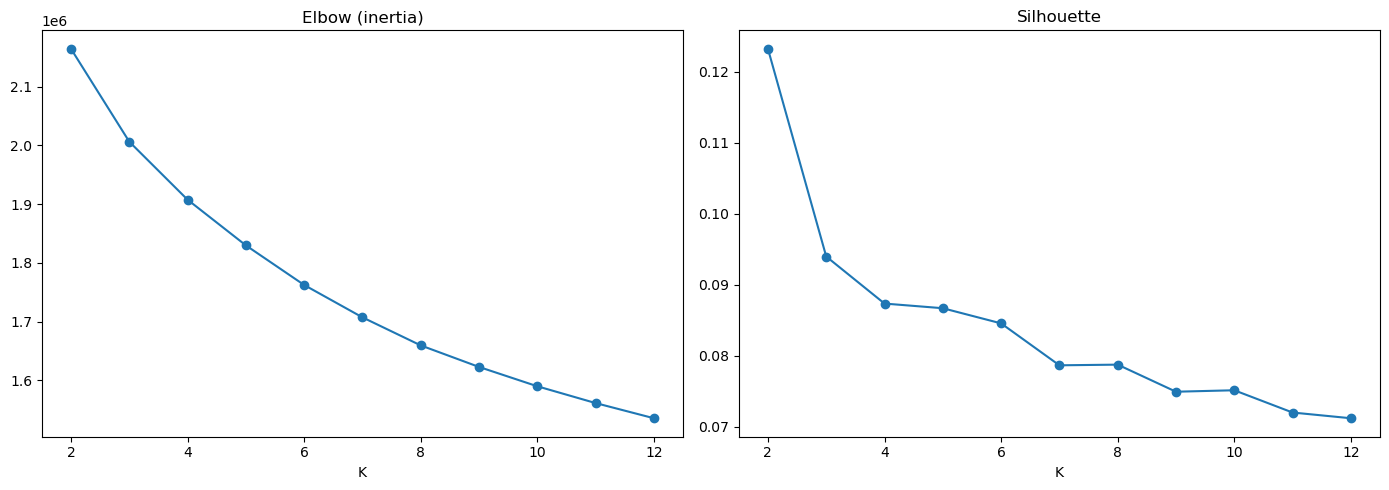

In [32]:
df_scaled_reduced = df_scaled.copy()
df_scaled_reduced = df_scaled_reduced[clustering_factors_reduced]

# Reduce the weighting of CLR columns so that they don't outweigh other factors (geometrically)
    # (7 CLR columns vs 6 behavioural columns means 'what customers by' carries a lot of the euclidean distance by column count)
clr_cols = [c for c in df_scaled_reduced.columns if c.startswith("clr_")]
clr_down_weighting = np.sqrt((len(clustering_factors_reduced)-len(clr_cols)) / len(clr_cols)) 
df_scaled_reduced[clr_cols] = df_scaled_reduced[clr_cols]*clr_down_weighting

# Repopulate graphs 
Ks = range(2, len(clustering_factors_reduced))
inertias, sils = [], []
samp_idx = df_scaled_reduced.sample(min(20000, len(df_scaled_reduced)), random_state=1).index
for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=1).fit(df_scaled_reduced)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(df_scaled_reduced.loc[samp_idx], km.predict(df_scaled_reduced.loc[samp_idx])))
 
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(list(Ks), inertias, marker="o"); ax[0].set_title("Elbow (inertia)"); ax[0].set_xlabel("K")
ax[1].plot(list(Ks), sils, marker="o");     ax[1].set_title("Silhouette");      ax[1].set_xlabel("K")
plt.tight_layout()
plt.show()

vvv Cluster-profile inspection — the z-score heatmap. Features with large-magnitude (very positive or very negative) standardized means in some cluster are the ones defining personas; features near zero everywhere aren't doing work? vvv

Next steps: + read on quality of seperation & the raw numbers above.

The tension - the metrics favour 3, but 3 personas is a weak product deliverable. Almost certainly collapses to the single biggest axis of variation (likely a produce-heavy-vs-not or reorder-heavy-vs-not split). Meanwhile the metrics give you no positive reason to prefer 5 over 6 over 7 — that region is flat.

Alternative situation - where silhouette stops being the decider and interpretability + stability take over. \
When the metric is flat across a range, you're free to choose within that range on other grounds, and the right grounds are:
1. Which K yields the most distinct, describable personas? Run K=4, 5, and 6, look at the z-score profile heatmap for each, and pick the one where the clusters tell the cleanest story — where each segment has a clear identity and you're not looking at two clusters that are obviously the same persona split in half. This is the primary criterion now.
2. Which K is most stable? Run your CELL 11 bootstrap ARI at 4, 5, and 6. Flat silhouette means the metric can't separate them, but stability can — the K that reproduces most consistently across resamples is the more defensible choice. This is where that stability step earns its keep; it's a tiebreaker precisely when silhouette is inconclusive.

- - - - - - - - - - -

## Selecting K by Stability & Distinctiveness

In [51]:
# Not selecting K based on seperation/silhouette (PCA sweep showed data is uninformative along a continum)


# Adjusted Rand Index (ARI) - used to evaluate the reproducibility and robustness of cluster assignments.
    # High = clustering reproduces across sample slices.
    # low = cluser assignment reshuffles --> group boundaries are arbitrary artifacts of the particular sample rather than real structure.
        # Higher avg ARI = more reproducible = safer to build personas on.

        # avg ARI > 0.90: Near identical/very stable boundaries
        # avg ARI > 0.75: Solid/defensible clustering - boundaries hold under perturbation
        # avg ARI > 0.50: Core structure holds with moderate flex in boundaries
        # avg ARI > 0.25: Weak reproducability - structure significantly artifact of subsample
        # avg ARI < 0.25: No stable structure

        # ari_std alongside:
            # low  (< ~0.05) = consistent; 
            # high (> ~0.15) = reproducibility itself unreliable (yellow light even if the mean is stronge)


#import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

# Stability sweep - reproduciblity at each K
def stability_by_k(Xs, k, n_iter=20, frac=0.8, seed=1):
    """Cluster full data (reference), then cluster n_iter random 80% subsamples;
    measure agreement with the reference on the overlapping customers via ARI."""
    ref = pd.Series(KMeans(k, n_init=10, random_state=seed).fit(Xs).labels_, index=Xs.index)
    rng = np.random.RandomState(seed)
    aris = []
    for _ in range(n_iter):
        s = Xs.sample(frac=frac, random_state=rng.randint(1_000_000))
        lab = KMeans(k, n_init=10, random_state=rng.randint(1_000_000)).fit_predict(s)
        aris.append(adjusted_rand_score(ref.loc[s.index], lab))
    return np.mean(aris), np.std(aris)

samp = df_scaled_reduced.sample(min(20000, len(df_scaled_reduced)), random_state=1).index
stab = []
for k in range(2, 9):
    m, s = stability_by_k(df_scaled_reduced, k)
    sil = silhouette_score(df_scaled_reduced.loc[samp],
                           KMeans(k, n_init=10, random_state=1).fit(df_scaled_reduced).predict(df_scaled_reduced.loc[samp]))
    stab.append({"K": k, "stability_ARI": round(m, 3), "ari_std": round(s, 3),
                 "silhouette": round(sil, 3)})
stab_df = pd.DataFrame(stab)
print(stab_df)

# Ojective: Identify the K with high stability_ARI AND low ari_std (consistent) --> largest K that still holds reasonable stability.
# Note: Silhouette is shown for context 

   K  stability_ARI  ari_std  silhouette
0  2           1.00     0.00        0.21
1  3           1.00     0.00        0.18
2  4           1.00     0.00        0.16
3  5           1.00     0.00        0.15
4  6           0.99     0.00        0.11
5  7           0.96     0.05        0.10
6  8           0.97     0.01        0.09


In [52]:
df_scaled_reduced

,reorder_pct,organic_pct,ln_avg_basket_size,ln_rsd_basket_size,rsd_days_since_prior,same_week_repurchase_pct,clr_produce,clr_dairy eggs,clr_meat seafood,clr_indulgence,clr_staples,clr_prepared,clr_non_consumables,cluster_k3,cluster_k4
user_id,,,,,,,,,,,,,,,
1,1.37,-0.08,-0.47,-0.69,-0.36,-1.15,-0.62,1.15,-0.59,2.23,-0.83,-2.79,0.78,0,3
2,-0.02,-0.13,0.95,0.08,0.23,-0.62,-0.08,0.63,-0.94,0.98,-0.64,0.94,-0.69,2,1
3,0.99,0.34,-0.25,-0.96,-0.48,0.18,0.72,0.82,-1.05,0.39,-0.47,-0.07,-0.30,1,1
4,-2.03,-0.82,-1.33,0.64,0.46,-1.15,-0.66,-2.19,0.12,0.29,-0.41,1.21,1.11,0,3
5,0.08,1.15,0.12,-0.93,-0.36,-0.23,0.89,0.66,-0.40,-0.72,-0.55,-0.31,0.25,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206205,-0.41,0.70,0.67,0.15,0.47,-1.15,0.51,1.66,0.70,-1.70,-1.59,1.05,-0.58,2,0
206206,-0.08,0.16,-1.09,1.51,1.16,1.89,-0.73,-0.20,-0.91,0.58,-0.45,0.88,0.70,1,1
206207,0.77,1.29,0.82,-0.11,0.90,0.31,0.11,0.77,0.49,0.37,0.55,0.40,-1.95,1,2


In [53]:

# --- 1b. Fit candidate Ks so you can inspect distinctiveness next ------------
CANDIDATE_KS = [3, 4, 6]
for k in CANDIDATE_KS:
    df_scaled_reduced[f"cluster_k{k}"] = KMeans(k, n_init=25, random_state=1).fit_predict(df_scaled_reduced)

df_scaled_reduced

,reorder_pct,organic_pct,ln_avg_basket_size,ln_rsd_basket_size,rsd_days_since_prior,same_week_repurchase_pct,clr_produce,clr_dairy eggs,clr_meat seafood,clr_indulgence,clr_staples,clr_prepared,clr_non_consumables,cluster_k3,cluster_k4,cluster_k6
user_id,,,,,,,,,,,,,,,,
1,1.37,-0.08,-0.47,-0.69,-0.36,-1.15,-0.62,1.15,-0.59,2.23,-0.83,-2.79,0.78,2,2,2
2,-0.02,-0.13,0.95,0.08,0.23,-0.62,-0.08,0.63,-0.94,0.98,-0.64,0.94,-0.69,1,1,5
3,0.99,0.34,-0.25,-0.96,-0.48,0.18,0.72,0.82,-1.05,0.39,-0.47,-0.07,-0.30,0,1,5
4,-2.03,-0.82,-1.33,0.64,0.46,-1.15,-0.66,-2.19,0.12,0.29,-0.41,1.21,1.11,2,2,3
5,0.08,1.15,0.12,-0.93,-0.36,-0.23,0.89,0.66,-0.40,-0.72,-0.55,-0.31,0.25,1,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206205,-0.41,0.70,0.67,0.15,0.47,-1.15,0.51,1.66,0.70,-1.70,-1.59,1.05,-0.58,1,3,4
206206,-0.08,0.16,-1.09,1.51,1.16,1.89,-0.73,-0.20,-0.91,0.58,-0.45,0.88,0.70,0,1,5
206207,0.77,1.29,0.82,-0.11,0.90,0.31,0.11,0.77,0.49,0.37,0.55,0.40,-1.95,0,0,1


In [54]:
X_scaled = df_scaled_reduced.copy()

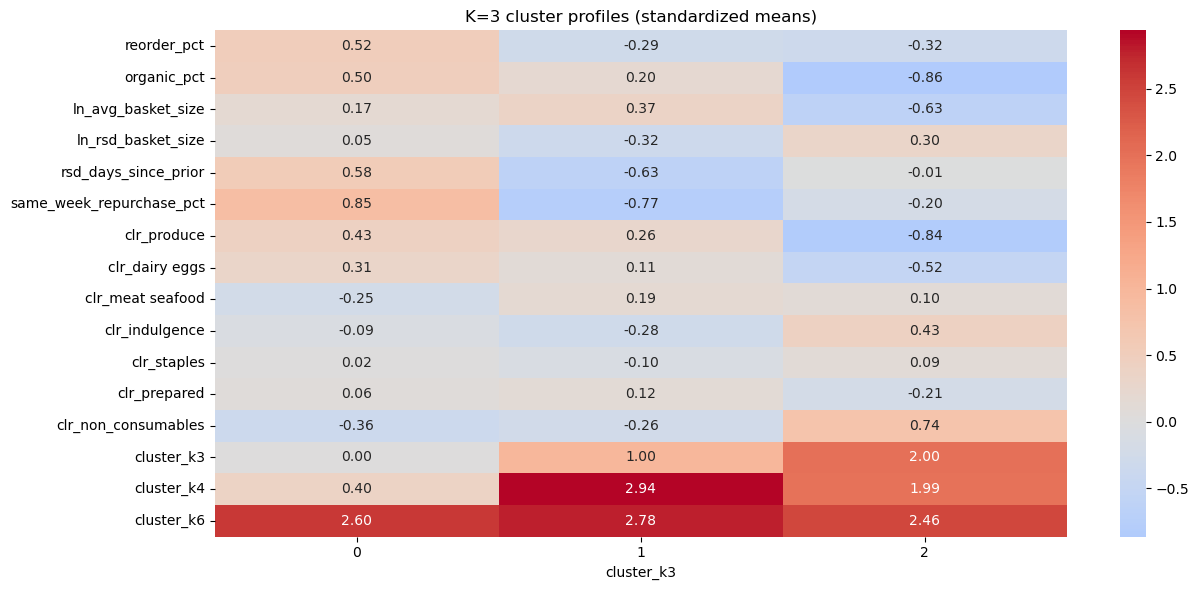

K=3 — min centroid distance between any two clusters: 2.92
cluster_k3    0    1    2
cluster_k3               
0          0.00 3.58 3.90
1          3.58 0.00 2.92
2          3.90 2.92 0.00


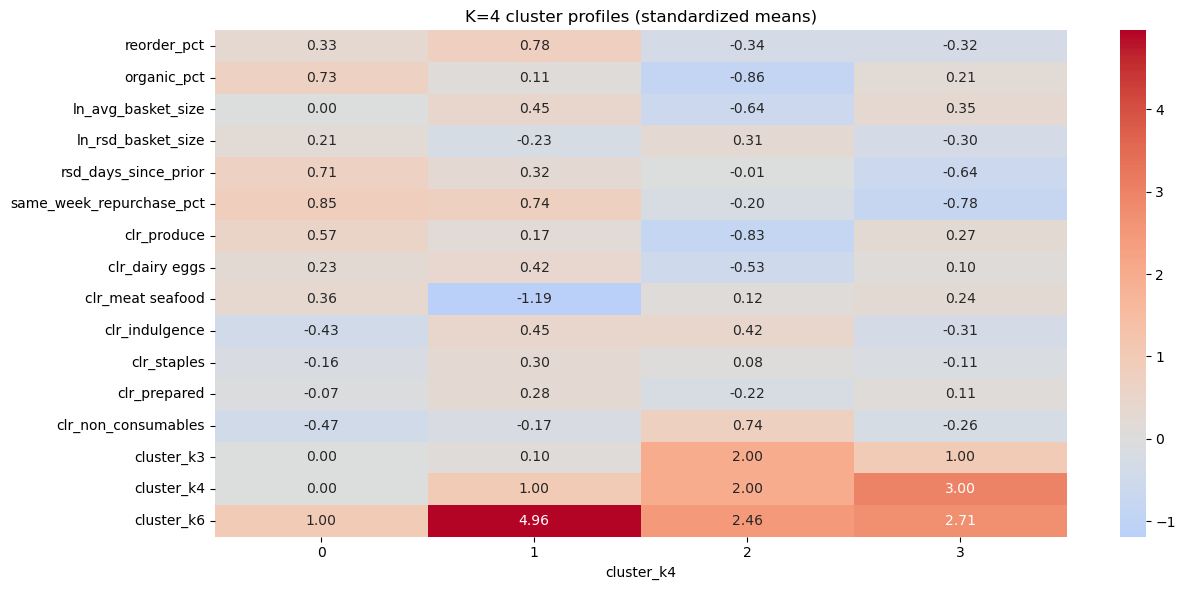

K=4 — min centroid distance between any two clusters: 2.94
cluster_k4    0    1    2    3
cluster_k4                    
0          0.00 4.65 4.48 4.32
1          4.65 0.00 4.50 4.15
2          4.48 4.50 0.00 2.94
3          4.32 4.15 2.94 0.00


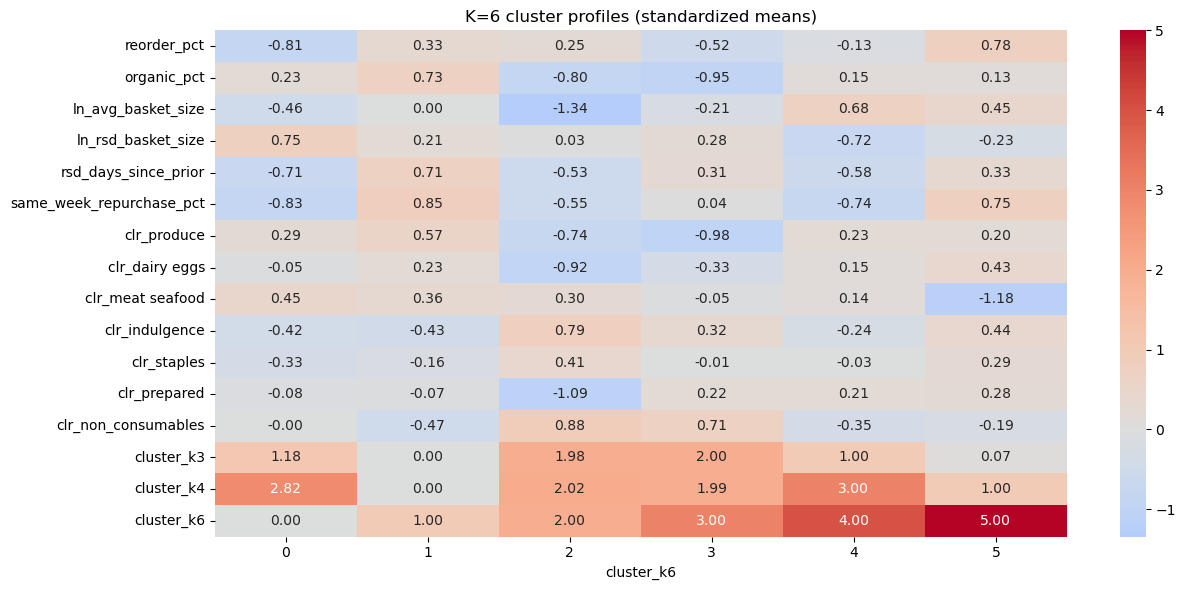

K=6 — min centroid distance between any two clusters: 2.59
cluster_k6    0    1    2    3    4    5
cluster_k6                              
0          0.00 4.20 3.81 4.14 4.53 6.45
1          4.20 0.00 4.93 4.61 5.04 4.67
2          3.81 4.93 0.00 2.59 4.27 5.35
3          4.14 4.61 2.59 0.00 3.28 4.12
4          4.53 5.04 4.27 3.28 0.00 3.52
5          6.45 4.67 5.35 4.12 3.52 0.00


In [56]:
# ==============================================================================
# STEP 2 — DISTINCTIVENESS: are the clusters actually different personas, or
#          near-duplicates? Judge from the profile heatmap + a similarity check.
# ==============================================================================
# WHY: at too-high K on soft data, KMeans splits one real archetype into look-alikes.
# The heatmap shows whether each cluster has a genuinely different signature.

def profile_and_check(k):
    labels = df_scaled_reduced[f"cluster_k{k}"]
    profile = X_scaled.groupby(labels).mean()            # standardized centroids

    # Heatmap: each column a persona; read the extreme (dark) cells as its identity.
    plt.figure(figsize=(13, 6))
    sns.heatmap(profile.T, cmap="coolwarm", center=0, annot=True, fmt=".2f")
    plt.title(f"K={k} cluster profiles (standardized means)")
    plt.tight_layout(); plt.show()

    # Quantify distinctiveness: pairwise distance between centroids. Small values =
    # two personas are near-duplicates = K may be too high.
    from scipy.spatial.distance import pdist, squareform
    d = pd.DataFrame(squareform(pdist(profile)), index=profile.index, columns=profile.index)
    print(f"K={k} — min centroid distance between any two clusters: {pdist(profile).min():.2f}")
    print(d.round(2))
    # RULE OF THUMB: if the closest pair is much smaller than the others, those two
    # are the same persona split in half -> prefer the smaller K.
    return profile

for k in CANDIDATE_KS:
    profile_and_check(k)



In [58]:
# DECISION POINT: choose your final K here based on (a) stability from Step 1,
# (b) whether every cluster in the heatmap tells a distinct story, (c) no two
# centroids nearly identical. Only then use "enough personas to be useful" to break
# a tie. Set it explicitly:
K_FINAL = 4
df_scaled_reduced["cluster"] = df_scaled_reduced[f"cluster_k{K_FINAL}"]

# --- OPTIONAL exploration: name the personas -------------------------------
# For each cluster, print its top +/- deviating features (its identity in words).
prof = X_scaled.groupby(df_scaled_reduced["cluster"]).mean()
for c in prof.index:
    top = prof.loc[c].reindex(prof.loc[c].abs().sort_values(ascending=False).index).head(5)
    print(f"\nCluster {c} (n={ (df_scaled_reduced['cluster']==c).sum() }): defining features")
    print(top.round(2))
# ITERATE: draft a persona label per cluster from these (e.g. "Organic Fresh Regular").
# Sanity-check against your 5 hypothesized personas — matches are reassuring, but
# don't force the data to fit them.


Cluster 0 (n=46141): defining features
cluster_k6                 1.00
same_week_repurchase_pct   0.85
organic_pct                0.73
rsd_days_since_prior       0.71
clr_produce                0.57
Name: 0, dtype: float64

Cluster 1 (n=33432): defining features
cluster_k6                  4.96
clr_meat seafood           -1.19
cluster_k4                  1.00
reorder_pct                 0.78
same_week_repurchase_pct    0.74
Name: 1, dtype: float64

Cluster 2 (n=59957): defining features
cluster_k6     2.46
cluster_k3     2.00
cluster_k4     2.00
organic_pct   -0.86
clr_produce   -0.83
Name: 2, dtype: float64

Cluster 3 (n=66665): defining features
cluster_k4                  3.00
cluster_k6                  2.71
cluster_k3                  1.00
same_week_repurchase_pct   -0.78
rsd_days_since_prior       -0.64
Name: 3, dtype: float64


In [42]:
df_scaled_reduced.drop(columns = ['cluster_k3', 'cluster_k4', 'cluster_k6'], inplace=True)
df_scaled_reduced

,reorder_pct,organic_pct,ln_avg_basket_size,ln_rsd_basket_size,rsd_days_since_prior,same_week_repurchase_pct,clr_produce,clr_dairy eggs,clr_meat seafood,clr_indulgence,clr_staples,clr_prepared,clr_non_consumables
user_id,,,,,,,,,,,,,
1,1.37,-0.08,-0.47,-0.69,-0.36,-1.15,-0.62,1.15,-0.59,2.23,-0.83,-2.79,0.78
2,-0.02,-0.13,0.95,0.08,0.23,-0.62,-0.08,0.63,-0.94,0.98,-0.64,0.94,-0.69
3,0.99,0.34,-0.25,-0.96,-0.48,0.18,0.72,0.82,-1.05,0.39,-0.47,-0.07,-0.30
4,-2.03,-0.82,-1.33,0.64,0.46,-1.15,-0.66,-2.19,0.12,0.29,-0.41,1.21,1.11
5,0.08,1.15,0.12,-0.93,-0.36,-0.23,0.89,0.66,-0.40,-0.72,-0.55,-0.31,0.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...
206205,-0.41,0.70,0.67,0.15,0.47,-1.15,0.51,1.66,0.70,-1.70,-1.59,1.05,-0.58
206206,-0.08,0.16,-1.09,1.51,1.16,1.89,-0.73,-0.20,-0.91,0.58,-0.45,0.88,0.70
206207,0.77,1.29,0.82,-0.11,0.90,0.31,0.11,0.77,0.49,0.37,0.55,0.40,-1.95


In [49]:
df_scaled_reduced

,reorder_pct,organic_pct,ln_avg_basket_size,ln_rsd_basket_size,rsd_days_since_prior,same_week_repurchase_pct,clr_produce,clr_dairy eggs,clr_meat seafood,clr_indulgence,clr_staples,clr_prepared,clr_non_consumables,cluster_k3,cluster_k4
user_id,,,,,,,,,,,,,,,
1,1.37,-0.08,-0.47,-0.69,-0.36,-1.15,-0.62,1.15,-0.59,2.23,-0.83,-2.79,0.78,0,3
2,-0.02,-0.13,0.95,0.08,0.23,-0.62,-0.08,0.63,-0.94,0.98,-0.64,0.94,-0.69,2,1
3,0.99,0.34,-0.25,-0.96,-0.48,0.18,0.72,0.82,-1.05,0.39,-0.47,-0.07,-0.30,1,1
4,-2.03,-0.82,-1.33,0.64,0.46,-1.15,-0.66,-2.19,0.12,0.29,-0.41,1.21,1.11,0,3
5,0.08,1.15,0.12,-0.93,-0.36,-0.23,0.89,0.66,-0.40,-0.72,-0.55,-0.31,0.25,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206205,-0.41,0.70,0.67,0.15,0.47,-1.15,0.51,1.66,0.70,-1.70,-1.59,1.05,-0.58,2,0
206206,-0.08,0.16,-1.09,1.51,1.16,1.89,-0.73,-0.20,-0.91,0.58,-0.45,0.88,0.70,1,1
206207,0.77,1.29,0.82,-0.11,0.90,0.31,0.11,0.77,0.49,0.37,0.55,0.40,-1.95,1,2


In [ ]:
TARGET_COLS = holdout_factors
# ==============================================================================
# STEP 3 — OUTCOME OVERLAY: the actual payoff. Do the (soft) archetypes separate
#          held-out variables they were NEVER clustered on?
# ==============================================================================
# WHY THIS IS THE MAIN EVENT: soft clusters can still differ on outcomes. If they
# do, you've shown shopping STYLE relates to business behaviour — the product-
# analytics result that matters more than any silhouette. If they don't, that's a
# real finding too (style is orthogonal to value).

# TARGET_COLS = held-out volume/exposure/cadence outcomes (never in the inputs).
overlay = df_joined.groupby("cluster")[TARGET_COLS].mean()
print("Held-out outcomes by archetype:")
print(overlay.round(2))

# Standardize the overlay so you can SEE which segments over/under-index on each
# outcome (raw means hide it when scales differ).
overlay_z = (overlay - df_joined[TARGET_COLS].mean()) / df_joined[TARGET_COLS].std()
plt.figure(figsize=(11, 5))
sns.heatmap(overlay_z.T, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Held-out outcomes by archetype (z-scored) — do segments separate?")
plt.tight_layout(); plt.show()

# --- 3a. Is the separation statistically real, or noise? ---------------------
# WHY: with 200k customers, tiny differences look "different." Test whether each
# outcome genuinely varies across clusters.
from scipy.stats import f_oneway
print("\nDo outcomes differ across clusters? (ANOVA)")
for col in TARGET_COLS:
    groups = [df_joined.loc[df_joined["cluster"] == c, col] for c in sorted(df_joined["cluster"].unique())]
    f, p = f_oneway(*groups)
    # effect size matters more than p at n=200k: eta^2 = between-var / total-var
    grand = df_joined[col].mean()
    ss_between = sum(len(g) * (g.mean() - grand) ** 2 for g in groups)
    ss_total = ((df_joined[col] - grand) ** 2).sum()
    eta2 = ss_between / ss_total
    print(f"  {col:26s} p={p:.1e}  eta^2={eta2:.3f}")
# READ THIS: at n=200k almost everything is "significant" (tiny p). The HONEST
# signal is eta^2 (share of variance the clustering explains): >0.06 ~ moderate,
# >0.14 ~ large; near 0 means the segments barely separate that outcome even if p
# is microscopic. Report eta^2, not just p.

# --- 3b. Marker prevalence by archetype (profilers) --------------------------
print("\nLifestyle marker prevalence by archetype vs baseline:")
#print(df_joined.groupby("cluster")[MARKER_COLS].mean().round(3))                   # def marker cols
#print("baseline:", df_joined[MARKER_COLS].mean().round(3).to_dict())

# --- OPTIONAL deeper analysis worth including --------------------------------
# 1. Retention proxy: if you can compute activity in the final third of each user's
#    order sequence, overlay it — "which archetypes fade?" is a strong product line.
# 2. Cross-tab archetype x T_hundred_orders or high/low value tier to see if style
#    predicts value tier.
# 3. Translate each archetype into ONE product action + the metric it should move
#    (the "what would Instacart DO differently" section) — this is what makes it
#    read as product analytics, not a clustering exercise.

Recomended steps:
- Pick K in the 4–5 range using profile-heatmap distinctness + bootstrap stability as the deciders (silhouette is flat, so it's demoted to a tiebreaker), not the noisy peaks.
- Whatever the final scores, write the honesty into the deliverable: report the modest silhouette, state that the structure is soft, show that you tried to improve it (the feature/PCA experiments), and justify the archetypes as actionable coarse-grainings rather than natural clusters.
- Then do the payoff analysis regardless — overlay the held-out retention/engagement/volume targets on whatever segments you land on. Here's the key point: even soft clusters can separate a held-out outcome, and if they do, that's your project's win. If your 4–5 archetypes show different retention or engagement trajectories despite modest silhouette, you've demonstrated the thing that actually matters — that behavioural style relates to business outcomes — and the low silhouette becomes a footnote, not the headline. And if they don't separate on outcomes, that's also a real, honest finding (shopping style is orthogonal to value)


### Temporary author notes:

Hierarchical clustering run on a 30K subsample due to its O(n²) memory footprint; used to validate K and structure.

Note:
- read the dendrogram for choosing K 
- cross-check that the same persona structure appears



import threading
print(len(threading.enumerate()))
threading.enumerate()

When to down-weight — a defensible rule. Down-weighting is for when a group of columns represents one conceptual axis but occupies many columns, so it dominates the distance purely by count. The clean test: does the number of columns in a block exceed the number of conceptual dimensions you want it to contribute? Your CLR block is 7 columns but arguably represents ~2–3 real axes of "what they buy" (fresh-vs-processed, indulgent-vs-staple, etc.). Meanwhile "how they shop" (reorder, discovery, cadence, timing, basket) is also ~5–6 real axes but spread across a similar column count. If composition ends up with disproportionate column count relative to its conceptual importance, K-means will over-weight it.
Two defensible strategies, in order of preference:

Compress rather than down-weight. Run PCA within the CLR block, keep the 2–3 components that capture its real dimensionality, and feed those instead of 7 raw columns. This is principled (you're representing the block by its actual dimensions) and sidesteps arbitrary weights — the cost is the PCA'd composition axes are less directly interpretable, so you'd describe segments' composition from the raw CLR means in profiling (Section 11) while clustering on the components.
Explicit down-weight, only if you want to keep raw interpretable columns: multiply the scaled block by a factor <1 so its total variance contribution roughly matches the behavioural block. The honest way to set the factor isn't by feel — it's to equalize the summed variance (or column count) across the two blocks, and to state the rule you used. Then run it both weighted and unweighted and report whether the personas change; if they don't, the weighting wasn't load-bearing and you note that; if they do, you've learned composition was dominating and the weighting is justified.

Summary: down-weight (or compress) a block when its column count overstates its conceptual importance and you can show the clustering shifts because of it. Don't down-weight on intuition alone — demonstrate the sensitivity.

The trajectory features (as targets - not inputs). Avg basket size early-vs-late, and avg cadence early-vs-late, are measuring how a customer's engagement changes over their lifecycle. Hold retention/engagement-trajectory out deliberately so the segments could explain it. 

"Do Convenience Shoppers show declining basket size over their lifecycle while Staples Buyers hold steady" is a genuinely good product finding, and it only works if trajectory was never an input.

Only analyze for customers that have greater than ?10?? orders???